# Customer Segmentation — Preprocessing & Feature Engineering
## Data Mining & Machine Learning | February 2026

**Sprint:** 2 | **User Stories:** US-3.1, US-3.2, US-3.3, US-3.4

---

### Notebook Objectives
1. Load raw data and apply all cleaning steps (US-3.1)
2. Engineer all derived features (US-3.2)
3. Encode categoricals and scale numeric features via pipeline (US-3.3)
4. PCA variance analysis and dimensionality justification (US-3.4)
5. Save `df_cleaned.csv`, scaled array, and `scaler.pkl` for downstream notebooks

## Section 1 — Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA

# Import project modules
from src.data_processing import (
    load_data, engineer_features,
    build_preprocessing_pipeline, prepare_features
)

sns.set_theme(style='whitegrid')
DATA_PATH    = '../data/raw/marketing_campaign.csv'
PROCESSED_DIR = '../data/processed'
MODELS_DIR   = '../models'
FIGURES_DIR  = '../figures'

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

## Section 2 — Load & Clean (US-3.1)

In [3]:
df_raw = load_data(DATA_PATH)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0


In [4]:
# Add this debug line in your notebook BEFORE calling engineer_features
df_raw = load_data(DATA_PATH)
print(df_raw['Marital_Status'].unique())
print(repr(df_raw[df_raw['Marital_Status'].str.contains('Alone', na=False)]['Marital_Status'].values))

['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']
array(['Alone', 'Alone', 'Alone'], dtype=object)


In [5]:
df_eng = engineer_features(df_raw)
print(f'After cleaning shape: {df_eng.shape}')
print(f'Rows dropped: {df_raw.shape[0] - df_eng.shape[0]}')
print()

# Verify no dirty values remain
print('Remaining Marital_Status values:')
print(df_eng['Marital_Status'].value_counts())
print()
print(f'Max Income: {df_eng["Income"].max():,.0f}')
print(f'Income nulls remaining: {df_eng["Income"].isnull().sum()}')

After cleaning shape: (2208, 39)
Rows dropped: 32

Remaining Marital_Status values:
Marital_Status
Married     857
Together    572
Single      471
Divorced    232
Widow        76
Name: count, dtype: int64

Max Income: 162,397
Income nulls remaining: 0


## Section 3 — Feature Engineering Summary (US-3.2)

In [6]:
engineered_features = ['Age', 'Customer_For_Days', 'Family_Size',
                        'TotalSpent', 'TotalPurchases',
                        'SpendPerPurchase', 'DealRate',
                        'WebChannelShare', 'CatalogChannelShare', 'StoreChannelShare']

print('Engineered features:')
df_eng[engineered_features].describe().round(3)

Engineered features:


,Age,Customer_For_Days,Family_Size,TotalSpent,TotalPurchases,SpendPerPurchase,DealRate,WebChannelShare,CatalogChannelShare,StoreChannelShare
count,2208.000,2208.000,2208.000,2208.000,2208.000,2208.000,2208.000,2208.000,2208.000,2208.000
mean,57.146,4672.479,2.594,607.434,20.195,26.208,0.114,0.329,0.165,0.504
std,11.751,202.328,0.906,603.380,7.286,25.811,0.067,0.122,0.141,0.151
min,30.000,4319.000,1.000,5.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,49.000,4499.000,2.000,69.000,14.000,5.000,0.062,0.250,0.000,0.400
50%,56.000,4674.000,3.000,396.000,19.000,17.246,0.100,0.333,0.150,0.500
75%,67.000,4848.000,3.000,1048.000,25.000,39.050,0.154,0.400,0.250,0.600
max,90.000,5018.000,5.000,2525.000,46.000,150.133,0.441,1.000,1.000,1.000


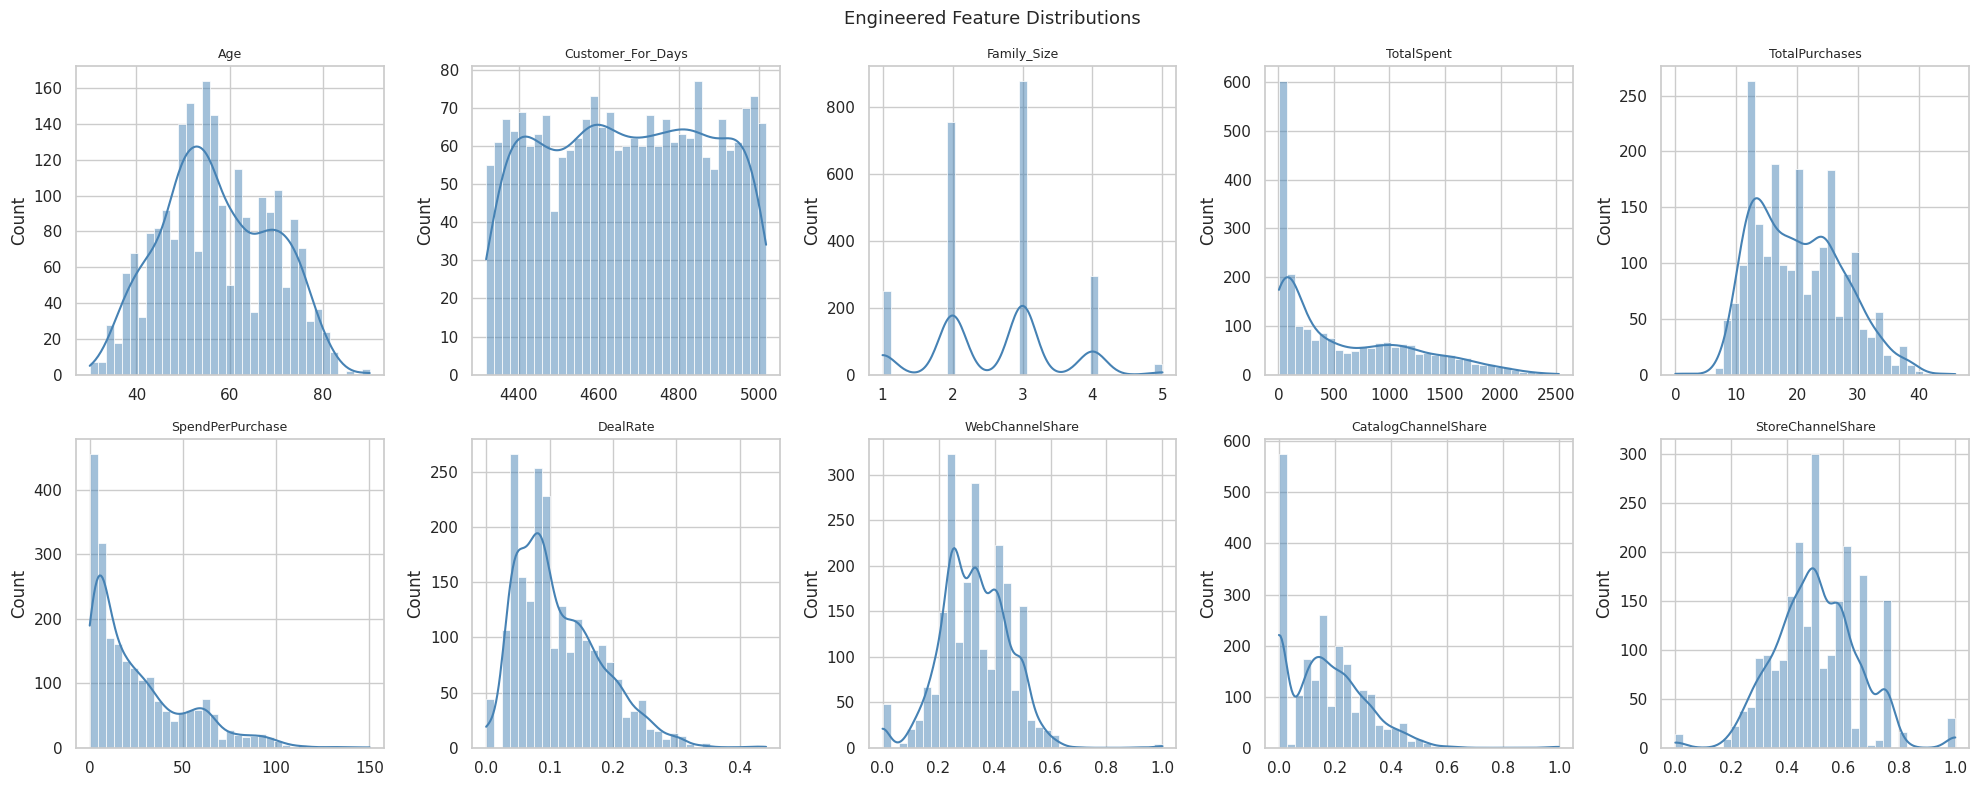

In [7]:
# Visualise key engineered features
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(engineered_features):
    sns.histplot(df_eng[col], ax=axes[i], kde=True, color='steelblue', bins=35)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Engineered Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Encoding & Scaling (US-3.3)

In [8]:
df_eng, X_df, pipeline = prepare_features(DATA_PATH)

print(f'Scaled feature matrix shape: {X_df.shape}')
print(f'\nFeature columns ({len(X_df.columns)} total):')
for col in X_df.columns:
    print(f'  {col}')

Scaled feature matrix shape: (2208, 24)

Feature columns (24 total):
  Age
  Income
  Kidhome
  Teenhome
  Recency
  Customer_For_Days
  TotalSpent
  TotalPurchases
  SpendPerPurchase
  DealRate
  NumWebVisitsMonth
  WebChannelShare
  CatalogChannelShare
  StoreChannelShare
  Education_2n Cycle
  Education_Basic
  Education_Graduation
  Education_Master
  Education_PhD
  Marital_Status_Divorced
  Marital_Status_Married
  Marital_Status_Single
  Marital_Status_Together
  Marital_Status_Widow


In [9]:
# Verify scaling — all numeric features should be ~N(0,1)
numeric_cols_check = ['Age', 'Income', 'TotalSpent', 'DealRate', 'WebChannelShare']
print('Post-scaling statistics (should be ~mean=0, std=1):')
X_df[numeric_cols_check].describe().round(3)

Post-scaling statistics (should be ~mean=0, std=1):


,Age,Income,TotalSpent,DealRate,WebChannelShare
count,2208.000,2208.000,2208.000,2208.000,2208.000
mean,-0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-2.311,-2.332,-0.999,-1.695,-2.698
25%,-0.693,-0.777,-0.893,-0.766,-0.646
50%,-0.098,-0.027,-0.350,-0.209,0.038
75%,0.839,0.769,0.730,0.590,0.585
max,2.797,5.127,3.179,4.858,5.510


In [10]:
# Save pipeline (scaler + encoder)
pipeline_path = f'{MODELS_DIR}/pipeline.pkl'
joblib.dump(pipeline, pipeline_path)
print(f'Pipeline saved to: {pipeline_path}')

# Save cleaned dataframe
clean_path = f'{PROCESSED_DIR}/df_cleaned.csv'
df_eng.to_csv(clean_path, index=False)
print(f'Cleaned data saved to: {clean_path}')

# Save scaled array
scaled_path = f'{PROCESSED_DIR}/X_scaled.npy'
np.save(scaled_path, X_df.values)
print(f'Scaled array saved to: {scaled_path}')

Pipeline saved to: ../models/pipeline.pkl
Cleaned data saved to: ../data/processed/df_cleaned.csv
Scaled array saved to: ../data/processed/X_scaled.npy


## Section 5 — PCA Variance Analysis (US-3.4)

In [11]:
# Cumulative explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_df)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_85 = np.argmax(cumvar >= 0.85) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

print(f'Components for 85% variance: {n_85}')
print(f'Components for 90% variance: {n_90}')
print(f'Components for 95% variance: {n_95}')
print(f'Total features: {X_df.shape[1]}')

Components for 85% variance: 9
Components for 90% variance: 11
Components for 95% variance: 14
Total features: 24


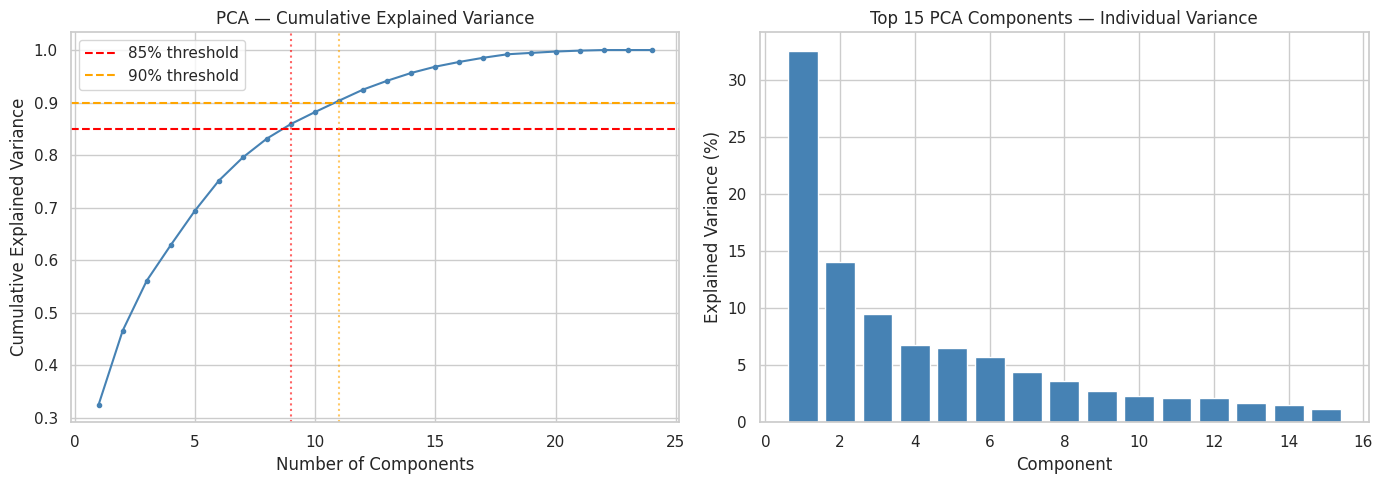

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative variance
axes[0].plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3, color='steelblue')
axes[0].axhline(0.85, color='red', linestyle='--', label='85% threshold')
axes[0].axhline(0.90, color='orange', linestyle='--', label='90% threshold')
axes[0].axvline(n_85, color='red', linestyle=':', alpha=0.6)
axes[0].axvline(n_90, color='orange', linestyle=':', alpha=0.6)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA — Cumulative Explained Variance')
axes[0].legend()
axes[0].grid(True)

# Individual variance per component
axes[1].bar(range(1, 16), pca_full.explained_variance_ratio_[:15] * 100, color='steelblue')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Explained Variance (%)')
axes[1].set_title('Top 15 PCA Components — Individual Variance')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/pca_variance.png', dpi=150)
plt.show()

In [13]:
# Reduce to 2D for all visualisations
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_df)

# Save 2D projection for modelling notebooks
np.save(f'{PROCESSED_DIR}/X_pca2d.npy', X_2d)
joblib.dump(pca_2d, f'{MODELS_DIR}/pca_2d.pkl')

print(f'2D PCA shape: {X_2d.shape}')
print(f'Variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.2%}')

2D PCA shape: (2208, 2)
Variance explained by 2 components: 46.63%


> **Decision:** The PCA 2D projection (`X_pca2d.npy`) is used **only for
> cluster visualisation** in `04_Evaluation.ipynb`. All three clustering algorithms
> train on the full scaled feature matrix (`X_scaled.npy`), not the reduced version.
> DBSCAN additionally receives the `n_85`-component reduction to mitigate the
> curse of dimensionality.

In [14]:
# Save n_85 reduced version for DBSCAN
pca_nd = PCA(n_components=n_85, random_state=42)
X_nd = pca_nd.fit_transform(X_df)
np.save(f'{PROCESSED_DIR}/X_pca_n85.npy', X_nd)
joblib.dump(pca_nd, f'{MODELS_DIR}/pca_nd.pkl')
print(f'Reduced array for DBSCAN: {X_nd.shape}')

Reduced array for DBSCAN: (2208, 9)


## Section 6 — Preprocessing Checklist

| Step | Status | Output |
|---|---|---|
| Load with correct sep + encoding | ✅ | `df_raw` |
| Drop dirty Marital_Status rows | ✅ | 7 rows removed |
| Remove Income outlier | ✅ | 1 row removed |
| Engineer Age, Tenure, Family_Size | ✅ | 3 new columns |
| Engineer TotalSpent, TotalPurchases | ✅ | 2 new columns |
| Engineer SpendPerPurchase, DealRate | ✅ | 2 new columns |
| Engineer channel share ratios | ✅ | 3 new columns |
| Median impute Income nulls | ✅ | via pipeline |
| One-hot encode Education, Marital_Status | ✅ | via pipeline |
| StandardScaler all numeric | ✅ | via pipeline |
| Save pipeline.pkl | ✅ | `models/pipeline.pkl` |
| Save df_cleaned.csv | ✅ | `data/processed/` |
| Save X_scaled.npy | ✅ | `data/processed/` |
| Save X_pca2d.npy | ✅ | `data/processed/` |
| Save X_pca_n85.npy (DBSCAN) | ✅ | `data/processed/` |